In [2]:
%pip install yaeos chemicals

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 1.8 MB/s  0:00:12 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.8/608.8 kB 1.4 MB/s  0:00:00? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [chemicals]━ 1/2 [chemicals]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Test yaeos features here!

This online notebook lets you run yaeos. It is possible to copy and paste
snippets of code from the [Tutorial section](https://ipqa-research.github.io/yaeos/page/python-api/tutorial/tutorial_tree.html).

## Model definition

Here we use the `chemicals` package to get the constants for a binary system
of methane-propane and define a PengRobinson model with them.

In [ ]:
import yaeos
import matplotlib.pyplot as plt
import numpy as np
import chemicals

components = ["methane", "propane"]

ids = [chemicals.CAS_from_any(name) for name in components]
Tc = [chemicals.critical.Tc(id) for id in ids]
Pc = [chemicals.critical.Pc(id) / 1e5 for id in ids]
w = [chemicals.acentric.omega(id) for id in ids]

model = yaeos.PengRobinson78(Tc, Pc, w)

## Phase envelope calculation
Calculate a phase envelope at $z = [0.3, 0.7]$

In [10]:
%%time
z = [0.3, 0.7]

env = model.phase_envelope_pt(z)

env

CPU times: user 30.1 ms, sys: 36 μs, total: 30.2 ms
Wall time: 29.4 ms


,T,P,x_1^1,w_1,x_2^1,w_2,beta^1
0,222.697945,1.000000,0.3,0.004038,0.7,9.959620e-01,1.0
1,223.368211,1.032407,0.3,0.004130,0.7,9.958701e-01,1.0
2,224.381815,1.082996,0.3,0.004272,0.7,9.957280e-01,1.0
3,225.920944,1.163567,0.3,0.004495,0.7,9.955050e-01,1.0
4,228.104062,1.285940,0.3,0.004827,0.7,9.951734e-01,1.0
...,...,...,...,...,...,...,...
192,56.016991,0.000026,0.3,1.000000,0.7,1.740577e-12,1.0
193,55.172523,0.000019,0.3,1.000000,0.7,1.053464e-12,1.0
194,54.322640,0.000014,0.3,1.000000,0.7,6.252112e-13,1.0
195,53.907817,0.000012,0.3,1.000000,0.7,4.816485e-13,1.0


### Plot the phase envelope

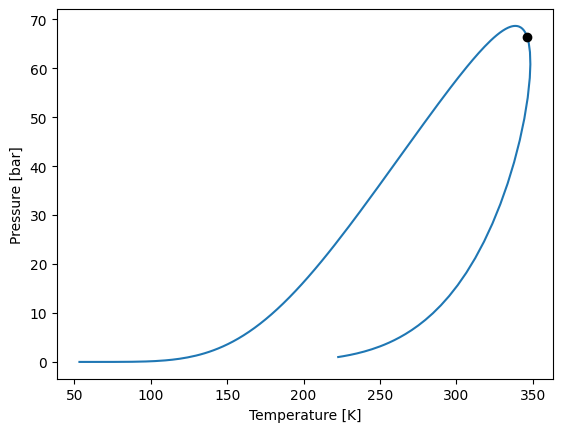

In [11]:
env.plot()